# MOFA+ and MOFA-Flex on DLBCL: variance explained and downstream biology

The imputation benchmark asked how well MOFA+ and MOFA-Flex *fill in* missing values. This
notebook asks the other half of the question: once each model is trained on the real DLBCL
data, what does it actually find? It trains both models once on the full, unmasked
RNA + protein data (no artificial masking), then looks at:

1. **Variance explained per factor, per view** - which factors are shared between RNA and
   protein, and which belong to one view only.
2. **Stability across seeds** - which factors come back when the model is retrained.
3. **Factor-metadata associations** - which factors line up with cell of origin, genetic
   subtypes, microenvironment and proliferation ranks, and ecotypes.
4. **Recovery of the ABC/GCB cell-of-origin axis** - the best-known biological axis in
   DLBCL, used as a positive control.
5. **Pathway enrichment of factor weights** (MSigDB Hallmark gene sets).
6. **Overall survival** - Cox models per factor.

"MOFA-Flex" here is the same model reported in the benchmark: MOFA-Flex with a GraphGP
weight prior built from the STRING protein network (stored as `MOFA-Flex-GraphGP` in the
benchmark checkpoints). The CRC cohort is left out, because its clinical metadata isn't
available for this project.

### Design choices

- **Features:** the 2,000 most variable features per view. Proteins must be observed in at
  least 50% of patients before the variance ranking, so the protein view isn't dominated by
  features that are mostly missing. (The benchmark used 500 features with no such filter,
  because it was measuring imputation, not biology.)
- **One joint model per method**, RNA and protein as two views. The 14 patients without RNA
  stay in the model; both methods treat their RNA view as missing.
- **15 factors**, the same as the benchmark. Both models' sparsity priors switch off factors
  they don't need.
- **Same scaling in both models:** every feature is centered and each view is scaled to unit
  variance (`scale_views=True` in MOFA+, which matches MOFA-Flex's Normal likelihood).
- **3 seeds per model.** Seed 0 is the reference model used for every downstream analysis;
  seeds 1 and 2 are only used to check which reference factors are reproducible.
- **Active factor:** explains at least 1% of the variance in at least one view. Only active
  factors are carried into the downstream analyses.

Trained models are saved under `results/mofa_downstream/models/`, along with each model's
factors, weights and variance explained as CSV files. Re-running the notebook reads those
files instead of retraining, unless `RETRAIN = True`.

In [1]:
# --- Cell 1: CPU budget, imports, paths, settings ---
import os
import time
import contextlib
import io as _io
import urllib.request
import warnings
from pathlib import Path


SHARED_NODE_MAX_THREADS = 8  # cap when nothing says how many cores this job owns


def _cluster_cpu_budget():
    """Same priority order as this project's other notebooks: IMPUTATION_CPU_BUDGET override,
    then the Slurm allocation. Unlike them, with neither set this does NOT take every core the
    process can see: an unmanaged node is shared with colleagues, so it uses at most
    SHARED_NODE_MAX_THREADS."""
    override = os.environ.get("IMPUTATION_CPU_BUDGET")
    if override and override.isdigit():
        return max(1, int(override)), "IMPUTATION_CPU_BUDGET override"
    for var in ("SLURM_CPUS_PER_TASK", "SLURM_CPUS_ON_NODE"):
        if os.environ.get(var, "").isdigit():
            return max(1, int(os.environ[var])), var
    visible = len(os.sched_getaffinity(0))
    return max(1, min(visible, SHARED_NODE_MAX_THREADS)), f"shared-node cap ({visible} cores visible)"


N_JOBS, _cpu_budget_source = _cluster_cpu_budget()
for _var in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
             "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_var] = str(N_JOBS)
print(f"CPU budget for this session: {N_JOBS} threads (source: {_cpu_budget_source})")

import numpy as np
import pandas as pd
import anndata as ad
import mudata as mu
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, mannwhitneyu, kruskal
from sklearn.metrics import roc_auc_score
from statsmodels.stats.multitest import multipletests
from statsmodels.duration.hazard_regression import PHReg
import torch
import mofaflex as mfl
from mofapy2.run.entry_point import entry_point

mu.set_options(pull_on_update=False)
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
torch.set_num_threads(N_JOBS)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"mofaflex device: {DEVICE}")

try:
    THIS_DIR = Path(__file__).resolve().parent
except NameError:
    THIS_DIR = Path.cwd()
BASE_DIR = THIS_DIR.parent

CANDIDATE_PROCESSED_DIRS = []
if os.environ.get("IMPUTATION_OUTPUT_DIR"):
    CANDIDATE_PROCESSED_DIRS.append(Path(os.environ["IMPUTATION_OUTPUT_DIR"]).expanduser())
CANDIDATE_PROCESSED_DIRS += [
    BASE_DIR / "data" / "processed",
    Path.home() / "reuben_imputation" / "processed",
    THIS_DIR / "processed",
]
PROCESSED_DIR = next((d for d in CANDIDATE_PROCESSED_DIRS if d.exists()), None)
if PROCESSED_DIR is None:
    raise FileNotFoundError("no 'processed' directory found among: " +
                            ", ".join(str(d) for d in CANDIDATE_PROCESSED_DIRS))

OUT_DIR = BASE_DIR / "results" / "mofa_downstream"
MODELS_DIR, TABLES_DIR, FIG_DIR = OUT_DIR / "models", OUT_DIR / "tables", OUT_DIR / "figures"
GENESET_DIR = BASE_DIR / "data" / "gene_sets"
for d in (MODELS_DIR, TABLES_DIR, FIG_DIR, GENESET_DIR):
    d.mkdir(parents=True, exist_ok=True)
print("processed dir:", PROCESSED_DIR, "| outputs:", OUT_DIR)

N_TOP_FEATURES = 2000      # per view
MIN_PROT_OBSERVED = 0.5    # a protein must be observed in >= 50% of patients
N_FACTORS = 15
SEEDS = [0, 1, 2]
REFERENCE_SEED = 0
ACTIVE_R2 = 0.01           # active factor: >= 1% variance explained in at least one view
STABLE_R = 0.8             # stable factor: |r| >= 0.8 with a factor in every other seed
FDR_ALPHA = 0.05
RETRAIN = False            # True retrains every model even if saved outputs exist

VIEWS = ["rna", "protein"]
MODELS = ["MOFA+", "MOFA-Flex"]  # the two models compared in Sections 1-6
# Section 7: MOFA-Flex variants that keep the STRING weight prior and add sparsity on the
# factors, plus a varimax rotation of the plain MOFA-Flex fits (no retraining).
SPARSE_VARIANTS = ["MOFA-Flex + Horseshoe factors", "MOFA-Flex + SpikeSlab factors"]
VARIMAX_MODEL = "MOFA-Flex, varimax-rotated"
ALL_MODELS = MODELS + SPARSE_VARIANTS + [VARIMAX_MODEL]
MODEL_TAG = {"MOFA+": "mofaplus", "MOFA-Flex": "mofaflex",
             "MOFA-Flex + Horseshoe factors": "mofaflex_horseshoe_factors",
             "MOFA-Flex + SpikeSlab factors": "mofaflex_spikeslab_factors"}
FACTOR_PRIOR = {"MOFA-Flex": "Normal", "MOFA-Flex + Horseshoe factors": "Horseshoe",
                "MOFA-Flex + SpikeSlab factors": "SpikeSlab"}
MODEL_COLOR = {"MOFA+": "#4d4d4d", "MOFA-Flex": "#7d3c98",  # same colors as the benchmark figures
               "MOFA-Flex + Horseshoe factors": "#1baf7a", "MOFA-Flex + SpikeSlab factors": "#eda100",
               VARIMAX_MODEL: "#2a78d6"}
COO_COLOR = {"ABC": "#eb6834", "GCB": "#2a78d6", "UNC": "#999999"}

CPU budget for this session: 8 threads (source: IMPUTATION_CPU_BUDGET override)


/home/rnjue/miniconda3/envs/mofaflex-gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



mofaflex device: cpu
processed dir: /home/rnjue/Imputationv2/data/processed | outputs: /home/rnjue/Imputationv2/results/mofa_downstream


### The data

RNA and protein come from the same `dlbcl_mudata_filtered.h5mu` file the benchmark uses.
Feature names are gene symbols in both views. To keep the two views apart inside the models,
every feature name gets a view prefix (`rna|MYC`, `protein|MYC`); the prefix is stripped again
for gene-level analyses.

In [2]:
# --- Cell 2: build the two views and the clinical metadata table ---
mdata = mu.read_h5mu(PROCESSED_DIR / "dlbcl_mudata_filtered.h5mu")
SAMPLES = list(mdata.obs_names)


def to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)


def view_frame(mod_key):
    """samples x features, gene-symbol columns (falls back to var_names for duplicate symbols)."""
    a = mdata.mod[mod_key]
    symbols = a.var["symbols"].astype(str)
    dup = symbols.duplicated(keep=False)
    cols = np.where(dup, a.var_names.astype(str), symbols)
    df = pd.DataFrame(to_dense(a.X), index=a.obs_names, columns=cols).reindex(SAMPLES)
    print(f"{mod_key}: {df.shape[1]} features, {int(dup.sum())} with a duplicated symbol kept under their var_name")
    return df


def top_variable(df, n):
    return df[df.var(axis=0, skipna=True).sort_values(ascending=False).index[:n]]


rna_all = view_frame("1_rna")
prot_all = view_frame("2_prot")
prot_observed = prot_all.notna().mean(axis=0)
prot_kept = prot_all.loc[:, prot_observed >= MIN_PROT_OBSERVED]
print(f"protein: {prot_kept.shape[1]} of {prot_all.shape[1]} proteins observed in >= "
      f"{MIN_PROT_OBSERVED:.0%} of patients")

VIEW_DATA = {
    "rna": top_variable(rna_all, N_TOP_FEATURES),
    "protein": top_variable(prot_kept, N_TOP_FEATURES),
}
FEATURE_NAMES = {v: [f"{v}|{g}" for g in VIEW_DATA[v].columns] for v in VIEWS}
RNA_PROFILED = mdata.obs["rna_profiled"].to_numpy()
for v in VIEWS:
    X = VIEW_DATA[v]
    print(f"{v}: {X.shape[0]} samples x {X.shape[1]} features, "
          f"{X.isna().all(axis=1).sum()} samples with no data in this view, "
          f"{X.isna().to_numpy().mean():.1%} missing overall")


def symbol_of(feature_name):
    return feature_name.split("|", 1)[1]


# Each view as both models see it: every feature centered, the whole view scaled to unit
# variance. Used to compute variance explained the same way for every model (Cell 4).
SCALED_VIEW = {}
for v in VIEWS:
    centered = VIEW_DATA[v] - VIEW_DATA[v].mean(axis=0)
    centered.columns = FEATURE_NAMES[v]
    SCALED_VIEW[v] = centered / np.sqrt(np.nanvar(centered.to_numpy()))


# Clinical metadata, cleaned into the variable types the association tests below expect.
obs = mdata.obs
meta = pd.DataFrame(index=SAMPLES)
meta["cell_of_origin"] = obs["cell_of_origin"].astype("object")
meta["LymphGen"] = obs["Lymphgen_Class_MYC"].astype("object")
meta["genetic_cluster"] = obs["cluster_AIC"].astype("object")
meta["ecotype"] = obs["ecotype"].astype("object")
meta["histology"] = obs["ICDO3"].astype("object")
meta["MHG"] = obs["MHG"].astype("object")
meta["double_triple_hit"] = obs["doub_trib_hit"].astype("object")
meta["stromal_rank"] = pd.to_numeric(obs["stromal_quantile_rank"].astype("object"), errors="coerce")
meta["proliferation_rank"] = pd.to_numeric(obs["prolif_quantile_rank"].astype("object"), errors="coerce")
meta["treatment"] = obs["rchop_real"].astype("object")
meta["OS_years"] = pd.to_numeric(obs["OS_Followup_Y"], errors="coerce")
meta["OS_event"] = pd.to_numeric(obs["OS_status"], errors="coerce")

# name -> (test type, groups to compare). Binary tests compare exactly two groups;
# categorical tests use every level with at least MIN_GROUP_N patients.
COVARIATES = {
    "cell_of_origin": ("binary", ("ABC", "GCB")),
    "LymphGen": ("categorical", None),
    "genetic_cluster": ("categorical", None),
    "ecotype": ("categorical", None),
    "histology": ("categorical", None),
    "MHG": ("binary", ("yes", "no")),
    "double_triple_hit": ("binary", ("yes", "no")),
    "stromal_rank": ("ordinal", None),
    "proliferation_rank": ("ordinal", None),
}
MIN_GROUP_N = 10
print("\ncell of origin:", meta["cell_of_origin"].value_counts(dropna=False).to_dict())
print("OS: ", int(meta["OS_event"].sum()), "deaths among", int(meta["OS_years"].notna().sum()), "patients with follow-up")

1_rna: 20314 features, 0 with a duplicated symbol kept under their var_name
2_prot: 6910 features, 0 with a duplicated symbol kept under their var_name
protein: 4666 of 6910 proteins observed in >= 50% of patients
rna: 332 samples x 2000 features, 14 samples with no data in this view, 4.2% missing overall
protein: 332 samples x 2000 features, 0 samples with no data in this view, 15.1% missing overall

cell of origin: {'GCB': 154, 'ABC': 88, 'UNC': 74, nan: 16}
OS:  172 deaths among 318 patients with follow-up


### STRING network basis for the MOFA-Flex weight prior

MOFA-Flex's GraphGP prior needs, for each view, the eigenvectors of the STRING
protein-interaction graph over that view's features (same construction and settings as
`evaluate_mofaflex_graphgp_multiomic_clinical.ipynb`: high-confidence edges, score >= 700,
150 eigenvectors). Edges are fetched live from STRING, so this cell needs internet access the
first time; the basis is then cached next to the models.

In [3]:
# --- Cell 3: STRING graph eigenbasis, one per view ---
N_GRAPH_BASIS = 150
SCORE_THRESHOLD = 700
SPECIES = 9606


def graph_eigenbasis(view):
    symbols = [symbol_of(f) for f in FEATURE_NAMES[view]]
    vec_path = MODELS_DIR / f"graph_eigvecs_{view}.csv"
    val_path = MODELS_DIR / f"graph_eigvals_{view}.npy"
    if vec_path.exists() and val_path.exists():
        vecs = pd.read_csv(vec_path, index_col=0)
        if list(vecs.index) == FEATURE_NAMES[view]:
            print(f"{view}: loaded cached eigenbasis {vecs.shape}")
            return vecs, np.load(val_path)
    unique = sorted(set(symbols))
    edges = mfl.tl.string_interactions(features=unique, species=SPECIES, score_threshold=SCORE_THRESHOLD)
    adjacency = mfl.tl.features_to_adjacency(unique, edges)
    coverage = mfl.tl.graph_coverage(unique, adjacency)
    print(f"{view}: STRING graph coverage: {coverage}")
    eigvecs, eigvals = mfl.tl.graph_feature_basis(adjacency, n_components=N_GRAPH_BASIS)
    row_of = {s: i for i, s in enumerate(unique)}
    vecs = pd.DataFrame(eigvecs[[row_of[s] for s in symbols]], index=FEATURE_NAMES[view],
                        columns=[f"eig_{i}" for i in range(eigvecs.shape[1])])
    vecs.to_csv(vec_path)
    np.save(val_path, np.asarray(eigvals))
    return vecs, np.asarray(eigvals)


GRAPH_BASIS = {v: graph_eigenbasis(v) for v in VIEWS}

rna: loaded cached eigenbasis (2000, 150)
protein: loaded cached eigenbasis (2000, 150)


### Training

Both models get the same two views, the same 15 factors and the same seeds. Each trained model
is saved to disk; its factors (patients x factors), weights (features x factors, per view) and
variance explained (views x factors) are written as CSV files, which is what the rest of the
notebook reads.

- **MOFA+** (`mofapy2`): spike-and-slab and ARD priors on the weights, closed-form variational
  updates, `medium` convergence (stricter than the benchmark's `fast`).
- **MOFA-Flex**: Normal factor prior, GraphGP weight prior per view, stochastic variational
  inference (5 particles, early stopping after 200 epochs without improvement). Same settings
  as the benchmark, with a higher epoch cap.

In [4]:
# --- Cell 4: training functions for both models ---
MOFAPLUS_MAX_ITER = 5000
MOFAFLEX_MAX_EPOCHS = 10000


def _output_paths(model_name, seed):
    stem = MODELS_DIR / f"{MODEL_TAG[model_name]}_seed{seed}"
    return {
        "model": stem.with_suffix(".hdf5" if model_name == "MOFA+" else ".pt"),
        "factors": Path(f"{stem}_factors.csv"),
        "r2": Path(f"{stem}_r2.csv"),
        **{f"weights_{v}": Path(f"{stem}_weights_{v}.csv") for v in VIEWS},
    }


def fit_mofaplus(seed, path):
    # mofapy2 0.7.5 stores train_options(seed=...) but never applies it (its np.random.seed call
    # is commented out), so seed numpy's global generator here to make each fit reproducible.
    np.random.seed(seed)
    ent = entry_point()
    ent.set_data_options(scale_views=True, scale_groups=False, center_groups=True)
    ent.set_data_matrix(
        [[VIEW_DATA[v].to_numpy()] for v in VIEWS], likelihoods=["gaussian"] * len(VIEWS),
        views_names=VIEWS, groups_names=["dlbcl"], samples_names=[SAMPLES],
        features_names=[FEATURE_NAMES[v] for v in VIEWS],
    )
    ent.set_model_options(factors=N_FACTORS, spikeslab_weights=True, spikeslab_factors=False,
                          ard_weights=True, ard_factors=False)
    ent.set_train_options(iter=MOFAPLUS_MAX_ITER, convergence_mode="medium", seed=seed,
                          gpu_mode=False, verbose=False, quiet=True)
    with contextlib.redirect_stdout(_io.StringIO()):
        ent.build()
        ent.run()
        ent.save(str(path), save_data=False)
    names = [f"F{k + 1}" for k in range(N_FACTORS)]
    factors = pd.DataFrame(ent.model.nodes["Z"].getExpectations()["E"], index=SAMPLES, columns=names)
    weights = {v: pd.DataFrame(w["E"], index=FEATURE_NAMES[v], columns=names)
               for v, w in zip(VIEWS, ent.model.nodes["W"].getExpectations())}
    r2 = pd.DataFrame(np.asarray(ent.model.calculate_variance_explained()[0]), index=VIEWS, columns=names)
    return factors, weights, r2


def variance_explained(factors, weights):
    """Per-factor and joint R^2 per view on SCALED_VIEW: 1 - residual SS / total SS over observed
    entries, the definition MOFA-Flex's get_r2() uses. Summing per-factor values overstates the
    joint total whenever factors are correlated, so the joint value is computed separately."""
    per_factor, total = {}, {}
    Z = factors.to_numpy()
    for v in VIEWS:
        Y = SCALED_VIEW[v].loc[factors.index, weights[v].index].to_numpy()
        obs = ~np.isnan(Y)
        Y0 = np.where(obs, Y, 0.0)
        ss = np.sum(Y0 ** 2)
        W = weights[v].to_numpy()
        per_factor[v] = [1 - np.sum(np.where(obs, Y0 - np.outer(Z[:, k], W[:, k]), 0.0) ** 2) / ss
                         for k in range(Z.shape[1])]
        total[v] = 1 - np.sum(np.where(obs, Y0 - Z @ W.T, 0.0) ** 2) / ss
    return pd.DataFrame(per_factor, index=factors.columns).T, pd.Series(total)


def fit_mofaflex(seed, path, factor_prior="Normal"):
    data = {"dlbcl": {}}
    for v in VIEWS:
        X = VIEW_DATA[v]
        X = X[X.notna().any(axis=1)]  # patients with no data in this view are simply left out of it
        a = ad.AnnData(X=X.to_numpy(dtype=np.float32))
        a.obs_names = X.index.astype(str)
        a.var_names = FEATURE_NAMES[v]
        a.varm["graph_eigvecs"] = GRAPH_BASIS[v][0].loc[FEATURE_NAMES[v]].to_numpy(dtype=np.float32)
        data["dlbcl"][v] = a
    weight_prior = {
        v: mfl.priors.GraphGP(eigenvectors_varm_key="graph_eigvecs",
                              eigenvalues=np.asarray(GRAPH_BASIS[v][1], dtype=np.float64),
                              kernel="diffusion", graph_confidence=0.9)
        for v in VIEWS
    }
    with contextlib.redirect_stdout(_io.StringIO()):
        model = mfl.terms.MofaFlex(n_factors=N_FACTORS, factor_prior=factor_prior, weight_prior=weight_prior)
        model.fit(data, likelihoods="Normal", device=DEVICE, max_epochs=MOFAFLEX_MAX_EPOCHS,
                  early_stopper_patience=200, n_particles=5, seed=seed, batch_size=0,
                  plot_data_overview=False, subset_var=None, remove_constant_features=False,
                  update_every=-1, save_path=str(path))
    term = model.terms["_"]
    raw_factors = term.get_factors()["dlbcl"]
    names = {c: f"F{k + 1}" for k, c in enumerate(raw_factors.columns)}
    factors = raw_factors.rename(columns=names).reindex(SAMPLES)
    weights = {v: w.rename(columns=names).reindex(FEATURE_NAMES[v]) for v, w in term.get_weights().items()}
    r2 = (model.get_r2().pivot(index="view", columns="component", values="R2")
          .rename(columns=names).reindex(index=VIEWS, columns=list(names.values())))
    return factors, weights, r2


def train_or_load(model_name, seed):
    paths = _output_paths(model_name, seed)
    if not RETRAIN and all(p.exists() for p in paths.values()):
        factors = pd.read_csv(paths["factors"], index_col=0)
        weights = {v: pd.read_csv(paths[f"weights_{v}"], index_col=0) for v in VIEWS}
        r2 = pd.read_csv(paths["r2"], index_col=0)
        return factors, weights, r2, None
    t0 = time.time()
    if model_name == "MOFA+":
        factors, weights, r2 = fit_mofaplus(seed, paths["model"])
    else:
        factors, weights, r2 = fit_mofaflex(seed, paths["model"], factor_prior=FACTOR_PRIOR[model_name])
    factors.to_csv(paths["factors"])
    r2.to_csv(paths["r2"])
    for v in VIEWS:
        weights[v].to_csv(paths[f"weights_{v}"])
    return factors, weights, r2, time.time() - t0

In [5]:
# --- Cell 5: train (or load) both models at every seed ---
FITS = {}


def train_all(model_names):
    for model_name in model_names:
        for seed in SEEDS:
            factors, weights, r2, seconds = train_or_load(model_name, seed)
            own_r2, r2_total = variance_explained(factors, weights)
            FITS[(model_name, seed)] = {"factors": factors, "weights": weights, "r2": r2, "r2_total": r2_total}
            how = "loaded from disk" if seconds is None else f"trained in {seconds / 60:.1f} min"
            print(f"{model_name} seed {seed}: {how}; variance explained by all factors jointly: "
                  + ", ".join(f"{v} {r2_total[v]:.1%}" for v in VIEWS)
                  + f" | per-factor R^2 check vs the model's own: max diff {(own_r2 - r2).abs().to_numpy().max():.4f}")


train_all(MODELS)

MOFA+ seed 0: loaded from disk; variance explained by all factors jointly: rna 47.4%, protein 41.6% | per-factor R^2 check vs the model's own: max diff 0.0000
MOFA+ seed 1: loaded from disk; variance explained by all factors jointly: rna 47.4%, protein 41.6% | per-factor R^2 check vs the model's own: max diff 0.0000


MOFA+ seed 2: loaded from disk; variance explained by all factors jointly: rna 47.4%, protein 41.6% | per-factor R^2 check vs the model's own: max diff 0.0000
MOFA-Flex seed 0: loaded from disk; variance explained by all factors jointly: rna 48.5%, protein 42.3% | per-factor R^2 check vs the model's own: max diff 0.0000


MOFA-Flex seed 1: loaded from disk; variance explained by all factors jointly: rna 48.3%, protein 42.5% | per-factor R^2 check vs the model's own: max diff 0.0000
MOFA-Flex seed 2: loaded from disk; variance explained by all factors jointly: rna 48.0%, protein 42.5% | per-factor R^2 check vs the model's own: max diff 0.0000


## 1. Variance explained per factor

For each model's reference fit (seed 0), factors are renumbered by total variance explained
(summed over both views), so Factor 1 is always the largest. A factor that explains variance
in both views captures signal that RNA and protein share; a factor that lights up in one view
only is specific to that data type.

The per-view totals on the right are computed from all factors *jointly*, not by adding up the
per-factor values: when factors are correlated (as MOFA-Flex's are), per-factor values overlap
and their sum overstates the total.

In [6]:
# --- Cell 6: order reference factors by variance explained; define active factors ---
def build_ref(model_name):
    fit = FITS[(model_name, REFERENCE_SEED)]
    order = fit["r2"].sum(axis=0).sort_values(ascending=False).index
    rename = {old: f"Factor {k + 1}" for k, old in enumerate(order)}
    r2 = fit["r2"][order].rename(columns=rename)
    active = [f for f in r2.columns if r2[f].max() >= ACTIVE_R2]
    print(f"{model_name}: {len(active)} active factors (>= {ACTIVE_R2:.0%} variance in at least one view)")
    return {
        "factors": fit["factors"][order].rename(columns=rename),
        "weights": {v: fit["weights"][v][order].rename(columns=rename) for v in VIEWS},
        "r2": r2,
        "r2_total": fit["r2_total"],
        "active": active,
        "native_name": {new: old for old, new in rename.items()},
    }


REF = {m: build_ref(m) for m in MODELS}

r2_table = pd.concat(
    {m: REF[m]["r2"].T.assign(active=lambda d, m=m: d.index.isin(REF[m]["active"])) for m in MODELS},
    names=["model", "factor"],
)
r2_table.to_csv(TABLES_DIR / "variance_explained_per_factor.csv")
(r2_table[VIEWS] * 100).round(2)

MOFA+: 15 active factors (>= 1% variance in at least one view)
MOFA-Flex: 15 active factors (>= 1% variance in at least one view)


rna  protein
model     factor                   
MOFA+     Factor 1   20.12     0.18
          Factor 2    0.03    10.48
          Factor 3    0.00     9.98
          Factor 4    1.93     5.15
          Factor 5    2.82     3.39
          Factor 6    5.21     0.11
          Factor 7    2.91     1.81
          Factor 8    0.44     3.98
          Factor 9    4.20     0.00
          Factor 10   3.14     0.98
          Factor 11   3.53     0.58
          Factor 12   0.24     2.64
          Factor 13   1.29     1.33
          Factor 14   2.38     0.22
          Factor 15   0.38     2.19
MOFA-Flex Factor 1    4.43     4.44
          Factor 2    4.65     3.72
          Factor 3    3.73     4.27
          Factor 4    5.16     2.40
          Factor 5    3.77     3.49
          Factor 6    4.86     2.36
          Factor 7    3.09     4.04
          Factor 8    4.93     1.84
          Factor 9    3.10     3.56
          Factor 10   2.85     3.71
          Factor 11   3.87     2.21
          Factor 12   3.57     2.46
          Factor 13   3.13     2.56
          Factor 14   3.58     2.08
          Factor 15   3.37     1.79

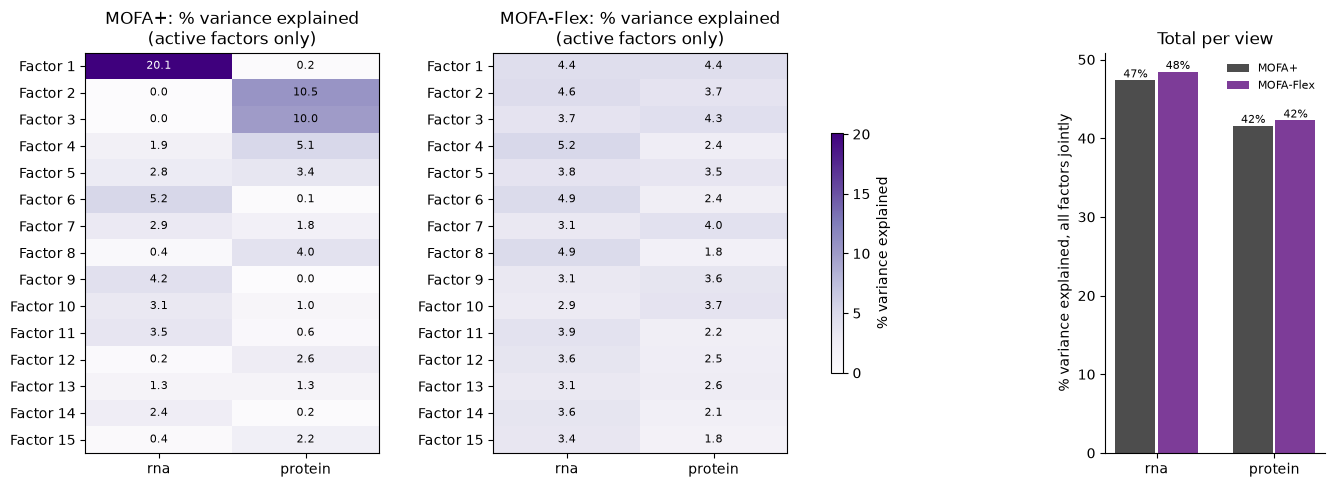

In [7]:
# --- Cell 7: Fig 1 - variance explained heatmaps and per-view totals ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), gridspec_kw={"width_ratios": [1, 1, 0.6], "wspace": 0.45})
vmax = max(REF[m]["r2"].to_numpy().max() for m in MODELS) * 100
for ax, model_name in zip(axes[:2], MODELS):
    r2 = REF[model_name]["r2"] * 100
    shown = r2.columns[: max(len(REF[model_name]["active"]), 1)]
    im = ax.imshow(r2[shown].T.to_numpy(), cmap="Purples", vmin=0, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(VIEWS)), VIEWS)
    ax.set_yticks(range(len(shown)), shown)
    for i, f in enumerate(shown):
        for j, v in enumerate(VIEWS):
            val = r2.loc[v, f]
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8,
                    color="white" if val > vmax * 0.6 else "black")
    ax.set_title(f"{model_name}: % variance explained\n(active factors only)")
fig.colorbar(im, ax=axes[:2], shrink=0.6, label="% variance explained")

ax = axes[2]
x = np.arange(len(VIEWS))
for k, model_name in enumerate(MODELS):
    totals = REF[model_name]["r2_total"].reindex(VIEWS) * 100
    bars = ax.bar(x + (k - 0.5) * 0.36, totals.values, width=0.34, color=MODEL_COLOR[model_name], label=model_name)
    ax.bar_label(bars, fmt="%.0f%%", fontsize=8)
ax.set_xticks(x, VIEWS)
ax.set_ylabel("% variance explained, all factors jointly")
ax.set_title("Total per view")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
fig.savefig(FIG_DIR / "fig1_variance_explained.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Are the factors reproducible?

Each model was trained with three seeds. For every active factor of the reference fit, the
table below gives its best absolute correlation with any factor of each other seed; a factor
is called **stable** when that correlation is at least 0.8 in every other seed. MOFA-Flex
trains by stochastic variational inference, so seed-to-seed differences are expected to be
larger there than for MOFA+.

The second figure matches the two models' reference factors to each other, to show which
axes both methods find.

MOFA+: 15 of 15 active factors stable across all seeds
MOFA-Flex: 0 of 15 active factors stable across all seeds


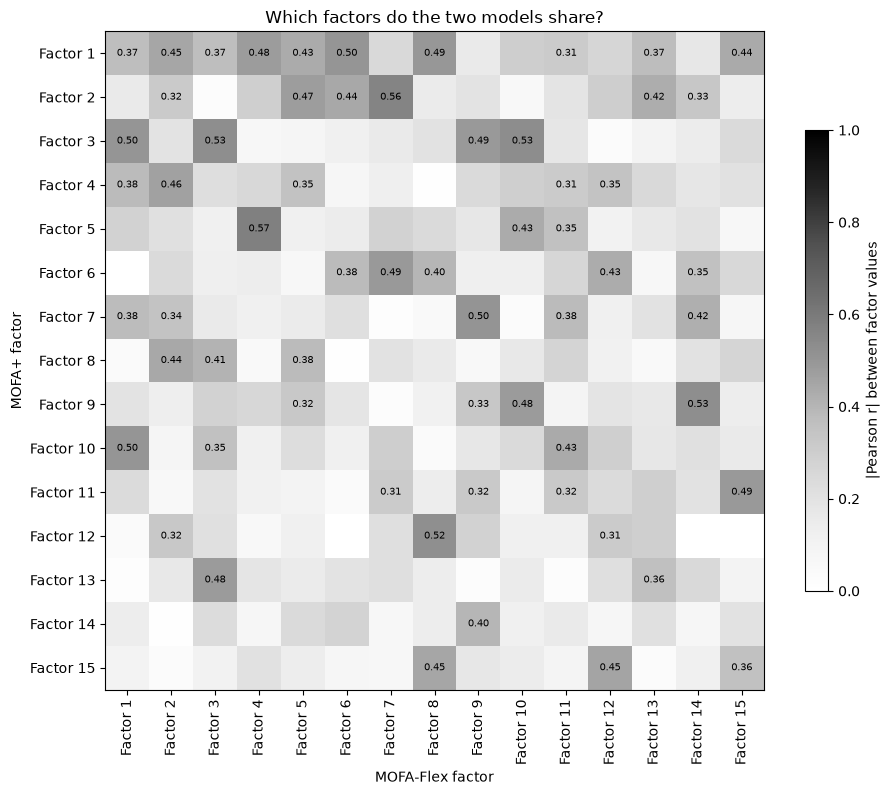

,model,factor,best |r| in seed 1,best |r| in seed 2,stable
0,MOFA+,Factor 1,1.000,1.000,True
1,MOFA+,Factor 2,1.000,1.000,True
2,MOFA+,Factor 3,1.000,1.000,True
3,MOFA+,Factor 4,1.000,1.000,True
4,MOFA+,Factor 5,1.000,1.000,True
5,MOFA+,Factor 6,1.000,1.000,True
6,MOFA+,Factor 7,1.000,1.000,True
7,MOFA+,Factor 8,1.000,1.000,True
8,MOFA+,Factor 9,1.000,1.000,True
9,MOFA+,Factor 10,1.000,1.000,True


In [8]:
# --- Cell 8: seed stability and MOFA+ vs MOFA-Flex factor correspondence ---
def abs_corr(A, B):
    """|Pearson r| between every column of A and every column of B (patients as rows)."""
    A = (A - A.mean()) / A.std()
    B = (B - B.mean()) / B.std()
    return (A.T @ B).abs() / (len(A) - 1)


stability_rows = []
for model_name in MODELS:
    ref = REF[model_name]
    for f in ref["active"]:
        row = {"model": model_name, "factor": f}
        for seed in SEEDS:
            if seed == REFERENCE_SEED:
                continue
            other = FITS[(model_name, seed)]
            other_active = [c for c in other["r2"].columns if other["r2"][c].max() >= ACTIVE_R2]
            row[f"best |r| in seed {seed}"] = abs_corr(ref["factors"][[f]], other["factors"][other_active]).max(axis=1).iloc[0]
        stability_rows.append(row)
stability = pd.DataFrame(stability_rows)
seed_cols = [c for c in stability.columns if c.startswith("best |r|")]
stability["stable"] = stability[seed_cols].min(axis=1) >= STABLE_R
stability.to_csv(TABLES_DIR / "factor_stability_across_seeds.csv", index=False)
for model_name in MODELS:
    s = stability[stability["model"] == model_name]
    print(f"{model_name}: {int(s['stable'].sum())} of {len(s)} active factors stable across all seeds")
STABLE = {m: stability.loc[(stability["model"] == m) & stability["stable"], "factor"].tolist() for m in MODELS}

corr_mm = abs_corr(REF["MOFA+"]["factors"][REF["MOFA+"]["active"]],
                   REF["MOFA-Flex"]["factors"][REF["MOFA-Flex"]["active"]])
corr_mm.to_csv(TABLES_DIR / "mofaplus_vs_mofaflex_factor_correlation.csv")

fig, ax = plt.subplots(figsize=(0.55 * corr_mm.shape[1] + 2.5, 0.45 * corr_mm.shape[0] + 1.8))
im = ax.imshow(corr_mm.to_numpy(), cmap="Greys", vmin=0, vmax=1)
ax.set_xticks(range(corr_mm.shape[1]), corr_mm.columns, rotation=90)
ax.set_yticks(range(corr_mm.shape[0]), corr_mm.index)
ax.set_xlabel("MOFA-Flex factor")
ax.set_ylabel("MOFA+ factor")
for i in range(corr_mm.shape[0]):
    for j in range(corr_mm.shape[1]):
        if corr_mm.iat[i, j] >= 0.3:
            ax.text(j, i, f"{corr_mm.iat[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if corr_mm.iat[i, j] > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.7, label="|Pearson r| between factor values")
ax.set_title("Which factors do the two models share?")
fig.savefig(FIG_DIR / "fig2_mofaplus_vs_mofaflex_factors.png", dpi=150, bbox_inches="tight")
plt.show()
stability.round(3)

### Unstable factors, or the same space rotated?

MOFA-Flex here uses a plain Normal prior on the factors, with no sparsity. Under that prior
the model can't tell a set of factors apart from any rotation of them, so different seeds can
return different factors that still describe the same space. That would look unstable
factor-by-factor while losing no information. Three checks separate the two readings:

1. **Seed-to-seed subspace agreement:** canonical correlations between the full factor sets of
   seed 0 and each other seed. Values near 1 mean the same space, whatever the individual
   factors look like.
2. **How much of each MOFA+ factor lies in MOFA-Flex's space:** R² from regressing each MOFA+
   factor on all 15 MOFA-Flex factors.
3. **Cell of origin from all factors together:** cross-validated logistic regression (ABC vs
   GCB, repeated stratified 5-fold) using every active factor, next to the best single
   factor. If MOFA-Flex matches MOFA+ here, the cell-of-origin signal is present but spread
   over several factors.

In [9]:
# --- Cell 8b: subspace checks ---
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def canonical_correlations(A, B):
    """Canonical correlations between the column spaces of A and B (patients as rows)."""
    qa, _ = np.linalg.qr(A - A.mean(axis=0))
    qb, _ = np.linalg.qr(B - B.mean(axis=0))
    return np.clip(np.linalg.svd(qa.T @ qb, compute_uv=False), 0, 1)


subspace_rows = []
for model_name in MODELS:
    ref = REF[model_name]["factors"][REF[model_name]["active"]].to_numpy()
    for seed in SEEDS:
        if seed == REFERENCE_SEED:
            continue
        other = FITS[(model_name, seed)]
        cols = [c for c in other["r2"].columns if other["r2"][c].max() >= ACTIVE_R2]
        cc = canonical_correlations(ref, other["factors"][cols].to_numpy())
        subspace_rows.append({"model": model_name, "compared with": f"seed {seed}",
                              "mean canonical r": cc.mean(), "min canonical r": cc.min(),
                              "n canonical r >= 0.9": int((cc >= 0.9).sum()), "n dimensions": len(cc)})
subspace = pd.DataFrame(subspace_rows)
subspace.to_csv(TABLES_DIR / "seed_subspace_agreement.csv", index=False)
print("1. Seed-to-seed subspace agreement")
display(subspace.round(3))

X_flex = REF["MOFA-Flex"]["factors"][REF["MOFA-Flex"]["active"]]
X_plus = REF["MOFA+"]["factors"][REF["MOFA+"]["active"]]
captured = pd.DataFrame({
    "MOFA+ factor": X_plus.columns,
    "R2 from all MOFA-Flex factors": [LinearRegression().fit(X_flex, X_plus[f]).score(X_flex, X_plus[f]) for f in X_plus],
    "best single MOFA-Flex |r|": corr_mm.max(axis=1).to_numpy(),
})
captured.to_csv(TABLES_DIR / "mofaplus_factors_in_mofaflex_space.csv", index=False)
print("2. How much of each MOFA+ factor lies in MOFA-Flex's factor space")
display(captured.round(3))

abc_gcb_rows = meta["cell_of_origin"].isin(["ABC", "GCB"])
y_coo = (meta.loc[abc_gcb_rows, "cell_of_origin"] == "ABC").astype(int)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)
coo_rows = []
for model_name in MODELS:
    X = REF[model_name]["factors"].loc[abc_gcb_rows, REF[model_name]["active"]]
    single = {f: max(a, 1 - a) for f in X for a in [roc_auc_score(y_coo, X[f])]}
    best_single = max(single, key=single.get)
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    aucs = cross_val_score(clf, X, y_coo, cv=cv, scoring="roc_auc")
    coo_rows.append({"model": model_name, "best single factor": best_single,
                     "single-factor AUC": single[best_single],
                     "all-factor AUC (cross-validated)": aucs.mean(), "CV AUC sd": aucs.std()})
coo_cv = pd.DataFrame(coo_rows)
coo_cv.to_csv(TABLES_DIR / "cell_of_origin_prediction.csv", index=False)
print("3. ABC vs GCB from one factor vs all factors together")
coo_cv.round(3)

1. Seed-to-seed subspace agreement


,model,compared with,mean canonical r,min canonical r,n canonical r >= 0.9,n dimensions
0,MOFA+,seed 1,1.000,1.000,15,15
1,MOFA+,seed 2,1.000,1.000,15,15
2,MOFA-Flex,seed 1,0.978,0.812,14,15
3,MOFA-Flex,seed 2,0.919,0.009,13,15


2. How much of each MOFA+ factor lies in MOFA-Flex's factor space


,MOFA+ factor,R2 from all MOFA-Flex factors,best single MOFA-Flex |r|
0,Factor 1,0.971,0.504
1,Factor 2,0.999,0.561
2,Factor 3,0.990,0.531
3,Factor 4,0.997,0.461
4,Factor 5,0.995,0.574
5,Factor 6,0.988,0.490
6,Factor 7,0.995,0.504
7,Factor 8,0.962,0.438
8,Factor 9,0.963,0.527
9,Factor 10,0.945,0.501


3. ABC vs GCB from one factor vs all factors together


,model,best single factor,single-factor AUC,all-factor AUC (cross-validated),CV AUC sd
0,MOFA+,Factor 5,0.883,0.890,0.043
1,MOFA-Flex,Factor 10,0.716,0.902,0.040


## 3. Which factors track the clinical and molecular annotations?

Every active factor is tested against each annotation:

- **Two groups** (ABC vs GCB cell of origin, MHG, double/triple hit): Mann-Whitney test, with
  the AUC as effect size. AUC is reported direction-free (0.5 = no separation, 1 = perfect),
  because a factor's sign is arbitrary.
- **Several groups** (LymphGen, genetic cluster, ecotype, histology): Kruskal-Wallis test over
  every group with at least 10 patients; effect size is epsilon-squared (share of rank variance
  explained by the grouping).
- **Ordered ranks** (stromal and proliferation quartile ranks): Spearman correlation.

P-values are corrected for multiple testing (Benjamini-Hochberg) within each model.

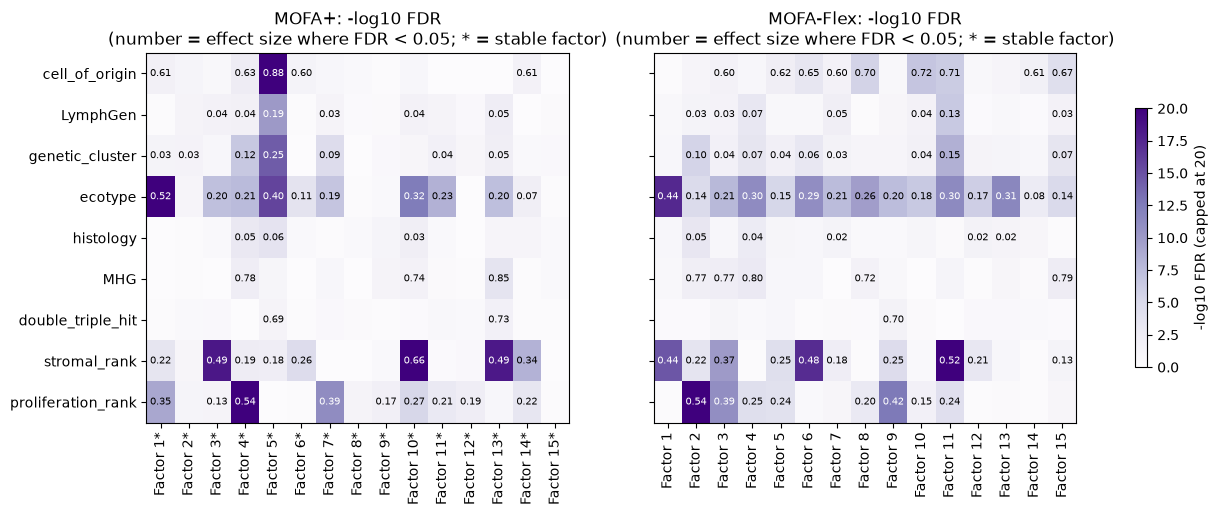

,model,factor,annotation,p,effect,effect_measure,n,fdr,stable_factor
88,MOFA+,Factor 10,stromal_rank,0.0,0.665,|Spearman rho|,318,0.0,True
35,MOFA+,Factor 4,proliferation_rank,0.0,0.536,|Spearman rho|,318,0.0,True
36,MOFA+,Factor 5,cell_of_origin,0.0,0.883,AUC,242,0.0,True
3,MOFA+,Factor 1,ecotype,0.0,0.517,epsilon^2,223,0.0,True
25,MOFA+,Factor 3,stromal_rank,0.0,0.490,|Spearman rho|,318,0.0,True
115,MOFA+,Factor 13,stromal_rank,0.0,0.488,|Spearman rho|,318,0.0,True
39,MOFA+,Factor 5,ecotype,0.0,0.401,epsilon^2,223,0.0,True
38,MOFA+,Factor 5,genetic_cluster,0.0,0.250,epsilon^2,316,0.0,True
84,MOFA+,Factor 10,ecotype,0.0,0.324,epsilon^2,223,0.0,True
62,MOFA+,Factor 7,proliferation_rank,0.0,0.390,|Spearman rho|,318,0.0,True


In [10]:
# --- Cell 9: factor-annotation association tests ---
def test_factor(values, covariate):
    kind, groups = COVARIATES[covariate]
    df = pd.DataFrame({"x": values, "y": meta[covariate]}).dropna()
    if kind == "binary":
        a = df.loc[df["y"] == groups[0], "x"]
        b = df.loc[df["y"] == groups[1], "x"]
        p = mannwhitneyu(a, b).pvalue
        auc = roc_auc_score(np.r_[np.ones(len(a)), np.zeros(len(b))], np.r_[a, b])
        return p, max(auc, 1 - auc), "AUC", len(a) + len(b)
    if kind == "categorical":
        sizes = df["y"].value_counts()
        df = df[df["y"].isin(sizes[sizes >= MIN_GROUP_N].index)]
        samples = [g["x"].to_numpy() for _, g in df.groupby("y")]
        h, p = kruskal(*samples)
        eps2 = (h - len(samples) + 1) / (len(df) - len(samples))
        return p, max(eps2, 0.0), "epsilon^2", len(df)
    rho, p = spearmanr(df["x"], df["y"])
    return p, abs(rho), "|Spearman rho|", len(df)


assoc_rows = []
for model_name in MODELS:
    factors = REF[model_name]["factors"]
    for f in REF[model_name]["active"]:
        for cov in COVARIATES:
            p, effect, effect_name, n = test_factor(factors[f], cov)
            assoc_rows.append({"model": model_name, "factor": f, "annotation": cov, "p": p,
                               "effect": effect, "effect_measure": effect_name, "n": n})
assoc = pd.DataFrame(assoc_rows)
assoc["fdr"] = assoc.groupby("model")["p"].transform(lambda p: multipletests(p, method="fdr_bh")[1])
assoc["stable_factor"] = [f in STABLE[m] for m, f in zip(assoc["model"], assoc["factor"])]
assoc.to_csv(TABLES_DIR / "factor_annotation_associations.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)
for ax, model_name in zip(axes, MODELS):
    sub = assoc[assoc["model"] == model_name]
    mat = sub.pivot(index="annotation", columns="factor", values="fdr").reindex(
        index=list(COVARIATES), columns=REF[model_name]["active"])
    eff = sub.pivot(index="annotation", columns="factor", values="effect").reindex_like(mat)
    score = -np.log10(mat.clip(lower=1e-30))
    im = ax.imshow(score.to_numpy(), cmap="Purples", vmin=0, vmax=min(20, np.nanmax(score.to_numpy())), aspect="auto")
    labels = [f"{f}*" if f in STABLE[model_name] else f for f in mat.columns]
    ax.set_xticks(range(mat.shape[1]), labels, rotation=90)
    ax.set_yticks(range(mat.shape[0]), mat.index)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if mat.iat[i, j] < FDR_ALPHA:
                ax.text(j, i, f"{eff.iat[i, j]:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if score.iat[i, j] > 10 else "black")
    ax.set_title(f"{model_name}: -log10 FDR\n(number = effect size where FDR < {FDR_ALPHA}; * = stable factor)")
fig.colorbar(im, ax=axes, shrink=0.7, label="-log10 FDR (capped at 20)")
fig.savefig(FIG_DIR / "fig3_factor_annotation_associations.png", dpi=150, bbox_inches="tight")
plt.show()

(assoc[assoc["fdr"] < FDR_ALPHA].sort_values(["model", "fdr"])
 .groupby("model").head(12).round({"p": 6, "fdr": 6, "effect": 3}))

## 4. Positive control: is the ABC/GCB cell-of-origin axis recovered?

ABC and GCB DLBCL differ in thousands of genes and proteins, so a factor model that captures
real biology should put this difference on one factor. For each model, the factor with the
highest ABC-vs-GCB AUC is taken as its cell-of-origin factor, oriented so that ABC is high.
Unclassified (UNC) tumours are shown too; they are expected to sit between ABC and GCB.

The weights of well-known cell-of-origin marker genes (Wright et al. 2003; Alizadeh et al.
2000) on that factor are a second check: ABC markers should load positively and GCB markers
negatively.

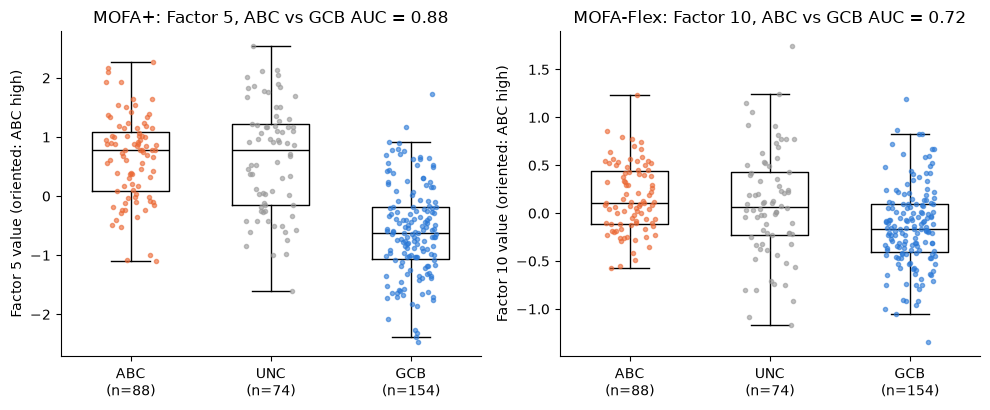

Marker weights on each model's cell-of-origin factor, scaled to the largest |weight| in that view (ABC markers should be > 0, GCB markers < 0). Only markers among the 2,000 selected features appear.


model                   MOFA+       MOFA-Flex      
view                  protein   rna   protein   rna
marker_group gene                                  
ABC marker   BATF         NaN  0.38       NaN -0.17
             BLNK        0.02   NaN     -0.12   NaN
             ENTPD1      0.26   NaN      0.13   NaN
             FOXP1       0.05   NaN      0.09   NaN
             IL16        0.13   NaN     -0.25   NaN
             IRF4        0.46   NaN      0.51   NaN
             PTPN1       0.39   NaN      0.11   NaN
             TCF4        0.20   NaN      0.13   NaN
GCB marker   DENND3       NaN -0.29       NaN -0.06
             ITPKB      -0.31   NaN     -0.20   NaN
             LRMP       -0.67   NaN     -0.48   NaN
             MME         0.00 -0.61     -0.07 -0.19
             MYBL1        NaN -0.60       NaN -0.68
             SERPINA9     NaN -1.00       NaN -0.84

In [11]:
# --- Cell 10: cell-of-origin factor, per model ---
ABC_MARKERS = ["IRF4", "PIM1", "CCND2", "FOXP1", "BATF", "ENTPD1", "BLNK", "IL16", "PTPN1", "TCF4", "SH3BP5", "ETV6"]
GCB_MARKERS = ["MME", "LMO2", "BCL6", "MYBL1", "SERPINA9", "NEK6", "LRMP", "ITPKB", "DENND3", "KLHL6"]

coo = meta["cell_of_origin"]
abc_gcb = coo.isin(["ABC", "GCB"])
COO_FACTOR = {}
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=False)
for ax, model_name in zip(axes, MODELS):
    factors = REF[model_name]["factors"][REF[model_name]["active"]]
    aucs = {f: roc_auc_score((coo[abc_gcb] == "ABC").astype(int), factors.loc[abc_gcb, f]) for f in factors}
    best = max(aucs, key=lambda f: abs(aucs[f] - 0.5))
    sign = 1 if aucs[best] >= 0.5 else -1
    COO_FACTOR[model_name] = (best, sign, max(aucs[best], 1 - aucs[best]))
    vals = sign * factors[best]
    for k, grp in enumerate(["ABC", "UNC", "GCB"]):
        y = vals[coo == grp].dropna()
        ax.boxplot(y, positions=[k], widths=0.55, showfliers=False, medianprops=dict(color="black"))
        jitter = np.random.default_rng(0).uniform(-0.18, 0.18, len(y))
        ax.scatter(k + jitter, y, s=9, alpha=0.6, color=COO_COLOR[grp], zorder=3)
    ax.set_xticks(range(3), [f"{g}\n(n={int((coo == g).sum())})" for g in ["ABC", "UNC", "GCB"]])
    ax.set_ylabel(f"{best} value (oriented: ABC high)")
    ax.set_title(f"{model_name}: {best}, ABC vs GCB AUC = {COO_FACTOR[model_name][2]:.2f}")
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_cell_of_origin_factor.png", dpi=150, bbox_inches="tight")
plt.show()

marker_rows = []
for model_name in MODELS:
    best, sign, auc = COO_FACTOR[model_name]
    for v in VIEWS:
        w = sign * REF[model_name]["weights"][v][best]
        w.index = [symbol_of(i) for i in w.index]
        w = w.groupby(level=0).mean()
        scale = w.abs().max()
        for group, genes in (("ABC marker", ABC_MARKERS), ("GCB marker", GCB_MARKERS)):
            for g in genes:
                if g in w.index:
                    marker_rows.append({"model": model_name, "factor": best, "view": v, "marker_group": group,
                                        "gene": g, "weight_scaled": w[g] / scale})
markers = pd.DataFrame(marker_rows)
markers.to_csv(TABLES_DIR / "cell_of_origin_marker_weights.csv", index=False)
print("Marker weights on each model's cell-of-origin factor, scaled to the largest |weight| in that view "
      "(ABC markers should be > 0, GCB markers < 0). Only markers among the 2,000 selected features appear.")
(markers.pivot_table(index=["marker_group", "gene"], columns=["model", "view"], values="weight_scaled")
 .round(2))

In [12]:
# --- Cell 11: agreement of the ABC/GCB direction with the marker genes ---
summary = (markers.assign(expected_sign=np.where(markers["marker_group"] == "ABC marker", 1, -1))
           .assign(agrees=lambda d: np.sign(d["weight_scaled"]) == d["expected_sign"])
           .groupby(["model", "view"])
           .agg(markers_present=("gene", "size"), sign_agrees=("agrees", "sum")))
summary["cell_of_origin_factor"] = [COO_FACTOR[m][0] for m in summary.index.get_level_values("model")]
summary["ABC_vs_GCB_AUC"] = [round(COO_FACTOR[m][2], 3) for m in summary.index.get_level_values("model")]
summary

markers_present  sign_agrees cell_of_origin_factor  \
model     view                                                          
MOFA+     protein               10            9              Factor 5   
          rna                    5            5              Factor 5   
MOFA-Flex protein               10            8             Factor 10   
          rna                    5            4             Factor 10   

                   ABC_vs_GCB_AUC  
model     view                     
MOFA+     protein           0.883  
          rna               0.883  
MOFA-Flex protein           0.716  
          rna               0.716

## 5. What biology do the factors carry? Hallmark pathway enrichment

For each active factor and each view, the weights of the genes in every MSigDB Hallmark gene
set are compared with the weights of all other features in that view (two-sided Mann-Whitney
test). A positive score means the gene set sits at the positive end of the factor; a negative
score, the negative end. Only gene sets with at least 10 members among the view's 2,000
features are tested, and the background is those 2,000 features, not the whole genome, so
the results describe what each factor does *within the most variable genes/proteins*. This
rank test is a simple stand-in for MOFA's own PCGSE enrichment.

In [13]:
# --- Cell 12: download (once) and read the Hallmark gene sets ---
HALLMARK_URL = "https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2024.1.Hs/h.all.v2024.1.Hs.symbols.gmt"
HALLMARK_PATH = GENESET_DIR / "h.all.v2024.1.Hs.symbols.gmt"
if not HALLMARK_PATH.exists():
    urllib.request.urlretrieve(HALLMARK_URL, HALLMARK_PATH)
GENE_SETS = {}
with open(HALLMARK_PATH) as fh:
    for line in fh:
        parts = line.rstrip("\n").split("\t")
        GENE_SETS[parts[0].replace("HALLMARK_", "")] = set(parts[2:])
print(f"{len(GENE_SETS)} Hallmark gene sets")
MIN_SET_SIZE = 10

50 Hallmark gene sets


In [14]:
# --- Cell 13: rank-based enrichment of factor weights ---
enrich_rows = []
for model_name in MODELS:
    for v in VIEWS:
        W = REF[model_name]["weights"][v][REF[model_name]["active"]].copy()
        W.index = [symbol_of(i) for i in W.index]
        W = W.groupby(level=0).mean()
        for set_name, genes in GENE_SETS.items():
            members = W.index.isin(genes)
            if members.sum() < MIN_SET_SIZE:
                continue
            for f in W.columns:
                inside, outside = W.loc[members, f], W.loc[~members, f]
                res = mannwhitneyu(inside, outside)
                auc = res.statistic / (len(inside) * len(outside))  # > 0.5: set sits at the positive end
                enrich_rows.append({"model": model_name, "view": v, "factor": f, "gene_set": set_name,
                                    "n_genes": int(members.sum()), "auc": auc, "p": res.pvalue})
enrich = pd.DataFrame(enrich_rows)
enrich["fdr"] = enrich.groupby("model")["p"].transform(lambda p: multipletests(p, method="fdr_bh")[1])
enrich["signed_score"] = np.sign(enrich["auc"] - 0.5) * -np.log10(enrich["fdr"].clip(lower=1e-30))
enrich.to_csv(TABLES_DIR / "hallmark_enrichment.csv", index=False)
print("gene sets tested per view:", enrich.groupby(["model", "view"])["gene_set"].nunique().to_dict())

top = (enrich[enrich["fdr"] < FDR_ALPHA].sort_values("fdr")
       .groupby(["model", "factor"]).head(4)
       .sort_values(["model", "factor", "fdr"]))
top[["model", "factor", "view", "gene_set", "n_genes", "auc", "fdr"]].round({"auc": 2, "fdr": 6})

gene sets tested per view: {('MOFA+', 'protein'): 44, ('MOFA+', 'rna'): 30, ('MOFA-Flex', 'protein'): 44, ('MOFA-Flex', 'rna'): 30}


,model,factor,view,gene_set,n_genes,auc,fdr
135,MOFA+,Factor 1,rna,EPITHELIAL_MESENCHYMAL_TRANSITION,40,0.25,0.000003
300,MOFA+,Factor 1,rna,INTERFERON_GAMMA_RESPONSE,17,0.20,0.000427
330,MOFA+,Factor 1,rna,KRAS_SIGNALING_UP,35,0.30,0.000752
120,MOFA+,Factor 1,rna,E2F_TARGETS,10,0.13,0.000934
144,MOFA+,Factor 10,rna,EPITHELIAL_MESENCHYMAL_TRANSITION,40,0.91,0.000000
...,...,...,...,...,...,...,...
1792,MOFA-Flex,Factor 8,protein,FATTY_ACID_METABOLISM,61,0.75,0.000000
1748,MOFA-Flex,Factor 9,protein,EPITHELIAL_MESENCHYMAL_TRANSITION,71,0.22,0.000000
1733,MOFA-Flex,Factor 9,protein,E2F_TARGETS,50,0.76,0.000000
1688,MOFA-Flex,Factor 9,protein,COAGULATION,55,0.27,0.000000


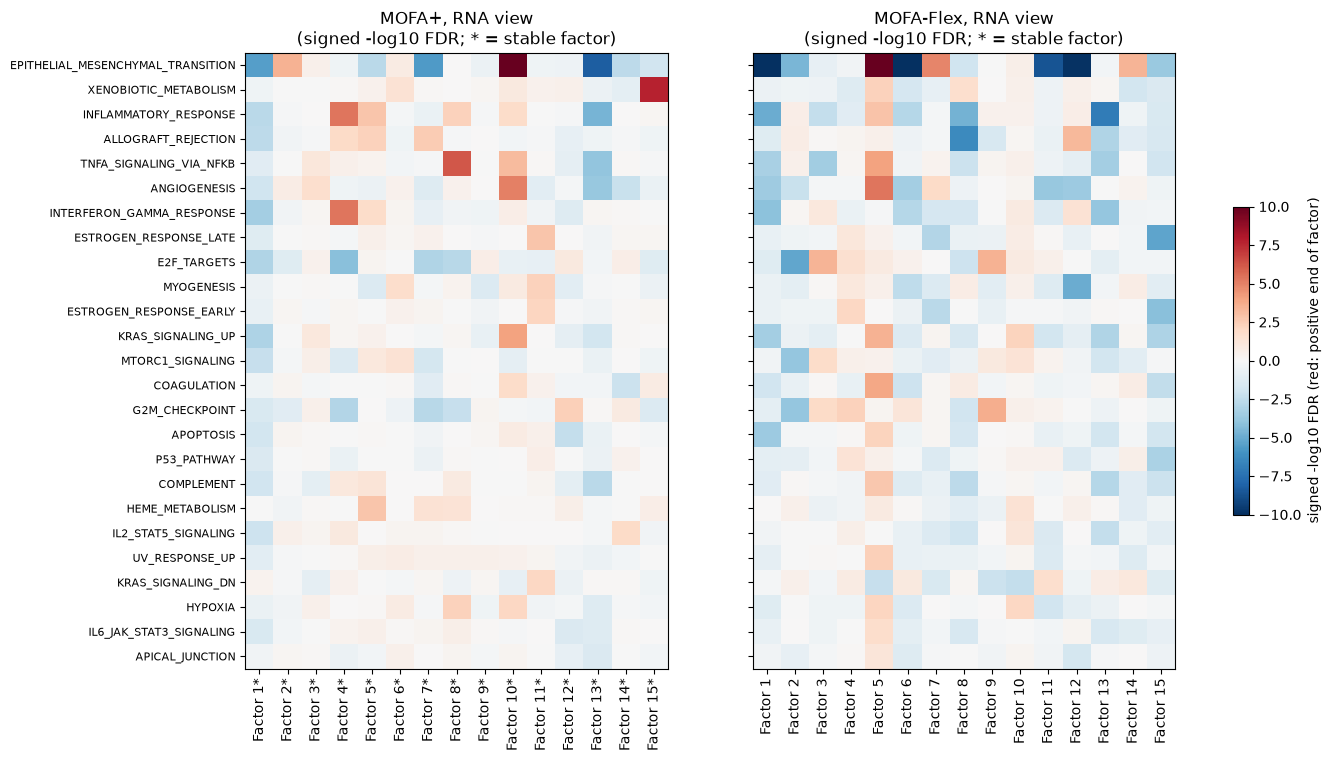

In [15]:
# --- Cell 14: Fig 5 - Hallmark enrichment heatmap (RNA view) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)
sig_sets = (enrich[(enrich["fdr"] < FDR_ALPHA) & (enrich["view"] == "rna")]
            .groupby("gene_set")["fdr"].min().sort_values().index[:25])
for ax, model_name in zip(axes, MODELS):
    sub = enrich[(enrich["model"] == model_name) & (enrich["view"] == "rna")]
    mat = sub.pivot(index="gene_set", columns="factor", values="signed_score").reindex(
        index=sig_sets, columns=REF[model_name]["active"])
    lim = 10
    im = ax.imshow(mat.clip(-lim, lim).to_numpy(), cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
    ax.set_xticks(range(mat.shape[1]), [f"{f}*" if f in STABLE[model_name] else f for f in mat.columns], rotation=90)
    ax.set_yticks(range(mat.shape[0]), mat.index, fontsize=8)
    ax.set_title(f"{model_name}, RNA view\n(signed -log10 FDR; * = stable factor)")
fig.colorbar(im, ax=axes, shrink=0.5, label="signed -log10 FDR (red: positive end of factor)")
fig.savefig(FIG_DIR / "fig5_hallmark_enrichment_rna.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Do any factors relate to overall survival?

Each active factor (standardized, so hazard ratios are per standard deviation) goes into a Cox
proportional-hazards model for overall survival. Two versions:

- **Treatment-stratified:** a separate baseline hazard for R-CHOP and other treatments, since
  treatment strongly affects survival but isn't what the factors are meant to explain.
- **Also adjusted for cell of origin:** asks whether a factor carries survival information
  beyond the known ABC/GCB/UNC split.

With 172 deaths this is enough for a first look, not a validated prognostic model; there is no
independent cohort to test anything on.

318 patients, 172 deaths; 302 with known cell of origin for the adjusted model


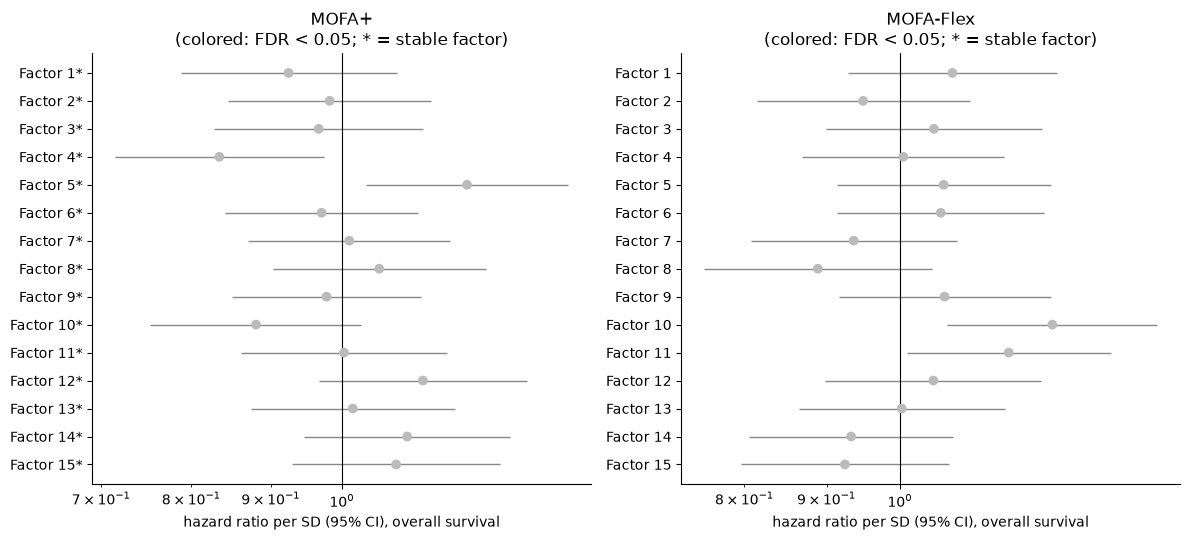

,model,factor,adjustment,HR_per_SD,CI_low,CI_high,p,n,fdr,stable_factor
6,MOFA+,Factor 4,treatment strata,0.83,0.71,0.97,0.02125,318,0.1593,True
8,MOFA+,Factor 5,treatment strata,1.20,1.04,1.40,0.01556,318,0.1593,True
48,MOFA-Flex,Factor 10,treatment strata,1.24,1.07,1.45,0.00441,318,0.0661,False


In [16]:
# --- Cell 15: Cox models per factor ---
surv = meta[["OS_years", "OS_event", "treatment", "cell_of_origin"]].dropna(subset=["OS_years", "OS_event", "treatment"])
surv = surv[surv["OS_years"] > 0]
coo_dummies = pd.get_dummies(surv["cell_of_origin"], dtype=float)[["ABC", "UNC"]]  # GCB = reference
coo_known = surv["cell_of_origin"].notna()


def cox(x, adjust_coo=False):
    z = (x - x.mean()) / x.std()
    exog = z.to_frame("factor")
    rows = surv.index
    if adjust_coo:
        rows = surv.index[coo_known]
        exog = pd.concat([exog.loc[rows], coo_dummies.loc[rows]], axis=1)
    res = PHReg(surv.loc[rows, "OS_years"], exog.loc[rows], status=surv.loc[rows, "OS_event"],
                strata=surv.loc[rows, "treatment"]).fit()
    b, se, p = res.params[0], res.bse[0], res.pvalues[0]
    return np.exp(b), np.exp(b - 1.96 * se), np.exp(b + 1.96 * se), p, len(rows)


cox_rows = []
for model_name in MODELS:
    factors = REF[model_name]["factors"].loc[surv.index]
    for f in REF[model_name]["active"]:
        for adjusted in (False, True):
            hr, lo, hi, p, n = cox(factors[f], adjust_coo=adjusted)
            cox_rows.append({"model": model_name, "factor": f,
                             "adjustment": "treatment strata + cell of origin" if adjusted else "treatment strata",
                             "HR_per_SD": hr, "CI_low": lo, "CI_high": hi, "p": p, "n": n})
cox_table = pd.DataFrame(cox_rows)
cox_table["fdr"] = cox_table.groupby(["model", "adjustment"])["p"].transform(lambda p: multipletests(p, method="fdr_bh")[1])
cox_table["stable_factor"] = [f in STABLE[m] for m, f in zip(cox_table["model"], cox_table["factor"])]
cox_table.to_csv(TABLES_DIR / "cox_overall_survival.csv", index=False)
print(f"{len(surv)} patients, {int(surv['OS_event'].sum())} deaths; "
      f"{int(coo_known.sum())} with known cell of origin for the adjusted model")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, model_name in zip(axes, MODELS):
    sub = cox_table[(cox_table["model"] == model_name) & (cox_table["adjustment"] == "treatment strata")]
    y = np.arange(len(sub))[::-1]
    colors = [MODEL_COLOR[model_name] if q < FDR_ALPHA else "#bbbbbb" for q in sub["fdr"]]
    ax.errorbar(sub["HR_per_SD"], y, xerr=[sub["HR_per_SD"] - sub["CI_low"], sub["CI_high"] - sub["HR_per_SD"]],
                fmt="none", ecolor="#888888", elinewidth=1)
    ax.scatter(sub["HR_per_SD"], y, color=colors, zorder=3)
    ax.axvline(1, color="black", lw=0.8)
    ax.set_xscale("log")
    ax.set_yticks(y, [f"{f}*" if s else f for f, s in zip(sub["factor"], sub["stable_factor"])])
    ax.set_xlabel("hazard ratio per SD (95% CI), overall survival")
    ax.set_title(f"{model_name}\n(colored: FDR < {FDR_ALPHA}; * = stable factor)")
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig6_cox_overall_survival.png", dpi=150, bbox_inches="tight")
plt.show()
cox_table[cox_table["fdr"] < 0.25].round({"HR_per_SD": 2, "CI_low": 2, "CI_high": 2, "p": 5, "fdr": 4})

## 7. Can sparsity make MOFA-Flex's factors interpretable?

Section 2 showed that MOFA-Flex finds the same space as MOFA+ but not the same individual
factors, because its plain Normal factor prior can't tell one rotation of the factors from
another. Three ways to pin the rotation down, all keeping the STRING GraphGP prior on the
weights:

1. **Horseshoe prior on the factors:** shrinks most patient scores toward zero while letting a
   few be large, and can shrink whole factors the model doesn't need (similar in effect to
   MOFA+'s ARD prior).
2. **Spike-and-slab prior on the factors:** each patient scores clearly on some factors and is
   set close to zero on the rest.
3. **Varimax rotation of the plain MOFA-Flex fits:** no retraining. Rotates each fit's factors
   (and weights, so the model's predictions are unchanged) to the orientation where each
   factor has a few large weights and many small ones, the standard way to choose a rotation
   in factor analysis. Variance explained is recomputed for the rotated factors.

Sparsity on the weights *together with* the STRING prior isn't possible in the installed
MOFA-Flex (one weight prior per view, and GraphGP's per-gene term is Gaussian), so it isn't
tested here.

Each variant gets the same checks as before: reproducibility across 3 seeds, how concentrated
the variance is, whether cell of origin lands on a single factor with the right marker genes,
and how closely single factors match MOFA+'s main axes.

In [17]:
# --- Cell 16: train (or load) the sparse-factor variants ---
train_all(SPARSE_VARIANTS)

MOFA-Flex + Horseshoe factors seed 0: loaded from disk; variance explained by all factors jointly: rna 48.5%, protein 42.3% | per-factor R^2 check vs the model's own: max diff 0.0000
MOFA-Flex + Horseshoe factors seed 1: loaded from disk; variance explained by all factors jointly: rna 48.4%, protein 42.4% | per-factor R^2 check vs the model's own: max diff 0.0000


MOFA-Flex + Horseshoe factors seed 2: loaded from disk; variance explained by all factors jointly: rna 48.1%, protein 42.5% | per-factor R^2 check vs the model's own: max diff 0.0000
MOFA-Flex + SpikeSlab factors seed 0: loaded from disk; variance explained by all factors jointly: rna 44.3%, protein 38.0% | per-factor R^2 check vs the model's own: max diff 0.0000


MOFA-Flex + SpikeSlab factors seed 1: loaded from disk; variance explained by all factors jointly: rna 44.6%, protein 37.7% | per-factor R^2 check vs the model's own: max diff 0.0000
MOFA-Flex + SpikeSlab factors seed 2: loaded from disk; variance explained by all factors jointly: rna 44.5%, protein 38.1% | per-factor R^2 check vs the model's own: max diff 0.0000


In [18]:
# --- Cell 17: varimax rotation of the plain MOFA-Flex fits ---
def varimax(L, max_iter=1000, tol=1e-10):
    """Kaiser's varimax: orthogonal R maximizing the variance of squared loadings of L @ R."""
    p, k = L.shape
    R = np.eye(k)
    objective = 0.0
    for _ in range(max_iter):
        Lr = L @ R
        u, s, vt = np.linalg.svd(L.T @ (Lr ** 3 - Lr @ np.diag((Lr ** 2).sum(axis=0)) / p))
        R = u @ vt
        if s.sum() < objective * (1 + tol):
            break
        objective = s.sum()
    return R


for seed in SEEDS:
    fit = FITS[("MOFA-Flex", seed)]
    names = list(fit["factors"].columns)
    stacked = np.vstack([fit["weights"][v].to_numpy() for v in VIEWS])  # both views share the factors
    R = varimax(stacked)
    factors = pd.DataFrame(fit["factors"].to_numpy() @ R, index=fit["factors"].index, columns=names)
    weights = {v: pd.DataFrame(fit["weights"][v].to_numpy() @ R, index=fit["weights"][v].index, columns=names)
               for v in VIEWS}
    r2, r2_total = variance_explained(factors, weights)
    assert (r2_total - fit["r2_total"]).abs().max() < 1e-6, "rotation must not change the model's fit"
    FITS[(VARIMAX_MODEL, seed)] = {"factors": factors, "weights": weights, "r2": r2, "r2_total": r2_total}
    print(f"varimax seed {seed}: joint variance explained unchanged "
          + ", ".join(f"{v} {r2_total[v]:.1%}" for v in VIEWS))

for model_name in SPARSE_VARIANTS + [VARIMAX_MODEL]:
    REF[model_name] = build_ref(model_name)

varimax seed 0: joint variance explained unchanged rna 48.5%, protein 42.3%


varimax seed 1: joint variance explained unchanged rna 48.3%, protein 42.5%


varimax seed 2: joint variance explained unchanged rna 48.0%, protein 42.5%
MOFA-Flex + Horseshoe factors: 15 active factors (>= 1% variance in at least one view)
MOFA-Flex + SpikeSlab factors: 15 active factors (>= 1% variance in at least one view)
MOFA-Flex, varimax-rotated: 15 active factors (>= 1% variance in at least one view)


In [19]:
# --- Cell 18: comparison of all five models on the same checks ---
def effective_n_factors(r2):
    """(sum of factor R^2)^2 / sum of squares: 1 if one factor carries everything, K if all equal."""
    s = r2.sum(axis=0)
    return s.sum() ** 2 / (s ** 2).sum()


def seed_checks(model_name):
    ref = REF[model_name]
    best_r, canon = [], []
    for seed in SEEDS:
        if seed == REFERENCE_SEED:
            continue
        other = FITS[(model_name, seed)]
        cols = [c for c in other["r2"].columns if other["r2"][c].max() >= ACTIVE_R2]
        best_r.append(abs_corr(ref["factors"][ref["active"]], other["factors"][cols]).max(axis=1))
        canon.append(canonical_correlations(ref["factors"][ref["active"]].to_numpy(), other["factors"][cols].to_numpy()))
    n_stable = int((pd.concat(best_r, axis=1).min(axis=1) >= STABLE_R).sum())
    return n_stable, float(np.mean([c.mean() for c in canon]))


def coo_checks(model_name):
    X = REF[model_name]["factors"].loc[abc_gcb_rows, REF[model_name]["active"]]
    aucs = {f: roc_auc_score(y_coo, X[f]) for f in X}
    best = max(aucs, key=lambda f: abs(aucs[f] - 0.5))
    sign = 1 if aucs[best] >= 0.5 else -1
    agree = present = 0
    for v in VIEWS:
        w = sign * REF[model_name]["weights"][v][best]
        w.index = [symbol_of(i) for i in w.index]
        w = w.groupby(level=0).mean()
        for genes, expected in ((ABC_MARKERS, 1), (GCB_MARKERS, -1)):
            for g in genes:
                if g in w.index:
                    present += 1
                    agree += int(np.sign(w[g]) == expected)
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    cv_auc = cross_val_score(clf, X, y_coo, cv=cv, scoring="roc_auc").mean()
    return best, max(aucs[best], 1 - aucs[best]), cv_auc, f"{agree}/{present}"


MOFAPLUS_AXES = {"cell of origin": COO_FACTOR["MOFA+"][0], "proliferation": "Factor 4",
                 "stroma": "Factor 10", "ecotype": "Factor 1"}
comparison_rows = []
for model_name in ALL_MODELS:
    ref = REF[model_name]
    n_stable, canon_mean = seed_checks(model_name)
    coo_best, coo_auc, coo_cv, marker_agree = coo_checks(model_name)
    row = {
        "model": model_name,
        "RNA R2 (joint)": ref["r2_total"]["rna"], "protein R2 (joint)": ref["r2_total"]["protein"],
        "active factors": len(ref["active"]),
        "effective no. of factors": effective_n_factors(ref["r2"][ref["active"]]),
        "largest factor R2 (sum of views)": ref["r2"].sum(axis=0).max(),
        "stable factors": f"{n_stable}/{len(ref['active'])}",
        "seed subspace mean canonical r": canon_mean,
        "COO best single-factor AUC": coo_auc,
        "COO all-factor CV AUC": coo_cv,
        "COO markers with expected sign": marker_agree,
    }
    for axis, plus_factor in MOFAPLUS_AXES.items():
        row[f"best |r| with MOFA+ {axis} factor"] = abs_corr(
            REF["MOFA+"]["factors"][[plus_factor]], ref["factors"][ref["active"]]).max(axis=1).iloc[0]
    comparison_rows.append(row)
comparison = pd.DataFrame(comparison_rows).set_index("model")
comparison.to_csv(TABLES_DIR / "sparsity_variants_comparison.csv")
comparison.T.round(3)

model,MOFA+,MOFA-Flex,MOFA-Flex + Horseshoe factors,MOFA-Flex + SpikeSlab factors,"MOFA-Flex, varimax-rotated"
RNA R2 (joint),0.473902,0.484656,0.484659,0.442882,0.484656
protein R2 (joint),0.416118,0.422909,0.422874,0.379719,0.422909
active factors,15,15,15,15,15
effective no. of factors,9.749743,14.677011,14.660369,14.337805,10.334064
largest factor R2 (sum of views),0.203016,0.088674,0.089484,0.074715,0.199671
stable factors,15/15,0/15,0/15,0/15,13/15
seed subspace mean canonical r,0.999998,0.94854,0.963367,0.739266,0.94854
COO best single-factor AUC,0.883338,0.715983,0.715909,0.689787,0.87345
COO all-factor CV AUC,0.889782,0.90221,0.902606,0.850655,0.901789
COO markers with expected sign,14/15,12/15,12/15,13/15,13/15


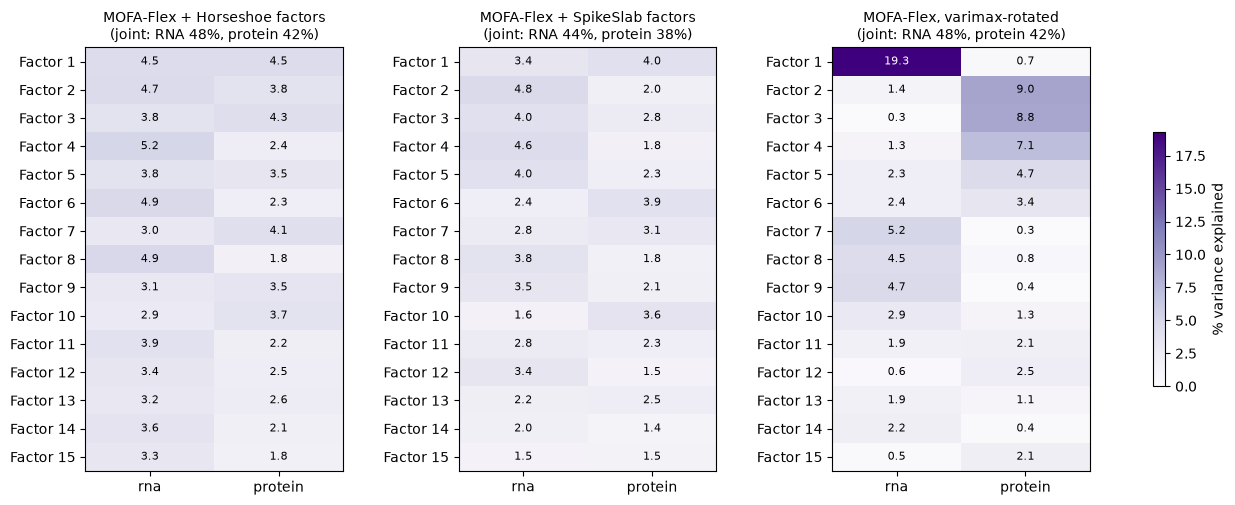

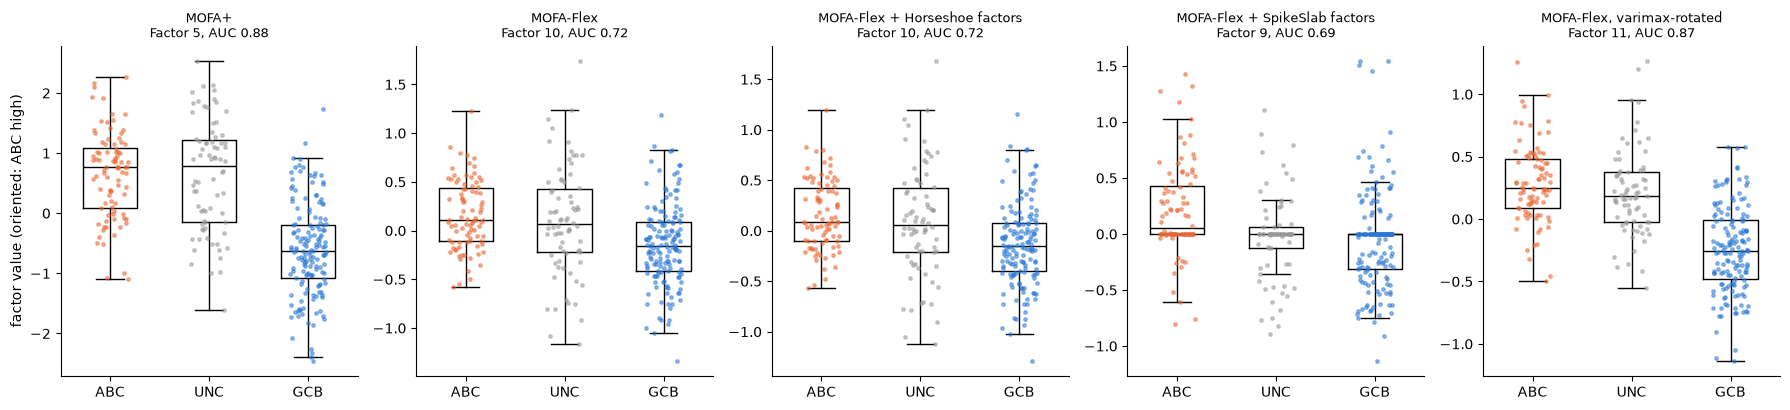

In [20]:
# --- Cell 19: Fig 7 - variance explained for the new variants; Fig 8 - cell-of-origin factor, all models ---
new_models = SPARSE_VARIANTS + [VARIMAX_MODEL]
fig, axes = plt.subplots(1, len(new_models), figsize=(5.4 * len(new_models), 5.5), gridspec_kw={"wspace": 0.45})
vmax = max(REF[m]["r2"].to_numpy().max() for m in new_models) * 100
for ax, model_name in zip(axes, new_models):
    r2 = REF[model_name]["r2"][REF[model_name]["active"]] * 100
    im = ax.imshow(r2.T.to_numpy(), cmap="Purples", vmin=0, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(VIEWS)), VIEWS)
    ax.set_yticks(range(r2.shape[1]), r2.columns)
    for i, f in enumerate(r2.columns):
        for j, v in enumerate(VIEWS):
            ax.text(j, i, f"{r2.loc[v, f]:.1f}", ha="center", va="center", fontsize=8,
                    color="white" if r2.loc[v, f] > vmax * 0.6 else "black")
    tot = REF[model_name]["r2_total"]
    ax.set_title(f"{model_name}\n(joint: RNA {tot['rna']:.0%}, protein {tot['protein']:.0%})", fontsize=10)
fig.colorbar(im, ax=axes, shrink=0.6, label="% variance explained")
fig.savefig(FIG_DIR / "fig7_variance_explained_sparsity_variants.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, len(ALL_MODELS), figsize=(3.6 * len(ALL_MODELS), 4.2))
for ax, model_name in zip(axes, ALL_MODELS):
    best, auc, _, _ = coo_checks(model_name)
    vals = REF[model_name]["factors"][best]
    if roc_auc_score(y_coo, vals.loc[abc_gcb_rows]) < 0.5:
        vals = -vals
    for k, grp in enumerate(["ABC", "UNC", "GCB"]):
        y = vals[coo == grp].dropna()
        ax.boxplot(y, positions=[k], widths=0.55, showfliers=False, medianprops=dict(color="black"))
        ax.scatter(k + np.random.default_rng(0).uniform(-0.18, 0.18, len(y)), y, s=6, alpha=0.5,
                   color=COO_COLOR[grp], zorder=3)
    ax.set_xticks(range(3), ["ABC", "UNC", "GCB"])
    ax.set_title(f"{model_name}\n{best}, AUC {auc:.2f}", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("factor value (oriented: ABC high)")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig8_cell_of_origin_all_models.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

**Variance explained.** Both models fit the data about equally well: taking all factors
together, MOFA+ explains 47% of RNA and 42% of protein variance, MOFA-Flex 48% and 42%. They
split that variance very differently. MOFA+ concentrates it: Factor 1 carries 20% of RNA
variance on its own, Factors 2 and 3 about 10% of protein variance each, and most factors
belong mainly to one view. MOFA-Flex spreads it evenly, 2-5% per factor, with all 15 factors
active in both views.

**Reproducibility.** MOFA+ returns the same 15 factors from every seed (|r| >= 0.9997).
MOFA-Flex matches none of its 15 factors across seeds (best |r| 0.45-0.72), but the *space*
its factors span is largely the same (13-14 of 15 canonical correlations >= 0.9). So the
instability is rotation, not noise: with a plain Normal prior on the factors and no sparsity,
MOFA-Flex has no reason to prefer one rotation of its factors over another.

**Biology recovered by MOFA+, each axis on its own factor:**

| Axis | MOFA+ factor | Evidence |
|---|---|---|
| Cell of origin (ABC vs GCB) | Factor 5 | AUC 0.88; 14 of 15 marker genes load with the expected sign; unclassified tumours sit between ABC and GCB |
| Proliferation | Factor 4 | Spearman rho 0.54 with proliferation rank; E2F and MYC targets in the protein weights |
| Stroma / microenvironment | Factor 10 (also 3, 13) | rho 0.66 with stromal rank; EMT and angiogenesis gene sets |
| Lymphoma ecotype | Factor 1 | epsilon^2 0.52; RNA-only, the largest factor |
| Unexplained protein programme | Factors 2 and 15 | protein-only, oxidative phosphorylation and fatty-acid metabolism, no clinical association |

Factors 2 and 15 explain a lot of protein variance but match no annotation. They could be a
real metabolic programme, or technical (sample handling, MS batch). They should be checked
against the proteomics batch/plate information before being interpreted as biology.

**MOFA-Flex holds the same information, spread across factors.** 14 of the 15 MOFA+ factors
are almost entirely captured by MOFA-Flex's factors taken together (R^2 0.93-0.999), yet no
single MOFA-Flex factor correlates above |r| 0.57 with any MOFA+ factor. Cell of origin shows
the same thing: MOFA-Flex's best single factor reaches AUC 0.72, but all its factors together
reach a cross-validated AUC of 0.90, level with MOFA+ (0.89 from all factors, 0.88 from
Factor 5 alone).

**Sparsity on the factors doesn't fix this; a varimax rotation does (Section 7).** All three
fixes kept the STRING GraphGP prior on the weights.

| | MOFA+ | MOFA-Flex | + Horseshoe factors | + SpikeSlab factors | varimax-rotated |
|---|---|---|---|---|---|
| Joint variance explained (RNA / protein) | 47% / 42% | 48% / 42% | 48% / 42% | 44% / 38% | 48% / 42% |
| Factors reproduced across seeds | 15/15 | 0/15 | 0/15 | 0/15 | 13/15 |
| Cell of origin, best single factor (AUC) | 0.88 | 0.72 | 0.72 | 0.69 | 0.87 |
| Best single-factor match to MOFA+ axes (\|r\|: cell of origin / proliferation / stroma / ecotype) | - | 0.57 / 0.46 / 0.50 / 0.50 | 0.57 / 0.46 / 0.51 / 0.50 | 0.50 / 0.38 / 0.44 / 0.45 | 0.77 / 0.73 / 0.81 / 0.98 |

- **Horseshoe factor prior:** no measurable effect. With the same seed its factors correlate
  r >= 0.996 with plain MOFA-Flex's; with 2,000 features per view the data outweighs a prior
  on the patient scores.
- **Spike-and-slab factor prior:** worse on every check: less variance explained, a less
  reproducible factor space (mean canonical r 0.74 vs 0.95), weaker cell-of-origin factor.
- **Varimax rotation:** no retraining and no change to the fit, but its factors become
  reproducible (13 of 15) and line up with MOFA+'s: the ecotype factor almost exactly
  (r = 0.98), stroma, cell of origin and proliferation clearly. Its variance pattern also
  becomes MOFA+-like (one RNA factor with 19%, several protein-dominated factors).

**Survival.** No factor is associated with overall survival after multiple-testing correction
(FDR < 0.05). The strongest signals point the expected way: the ABC end of the
cell-of-origin factor goes with worse survival (MOFA+ Factor 5, HR 1.20 per SD, p = 0.016;
MOFA-Flex Factor 10, HR 1.24, p = 0.004, FDR 0.07). The proliferation factor (MOFA+ Factor 4,
HR 0.83, p = 0.021) keeps its effect after adjusting for cell of origin (p = 0.027).

**What this means.** MOFA+ is the better-behaved model for reading biology off individual
factors on this data: stable, and it puts known DLBCL axes on separate factors. MOFA-Flex with
the STRING prior captures the same information; after a varimax rotation its factors are
nearly as interpretable and reproducible as MOFA+'s. Sparsity on the factors is not the right
lever here. Sparsity on the weights together with the STRING prior would be the natural next
test, but it needs a new prior in MOFA-Flex itself.

**Caveats.** All analyses use the 2,000 most variable features per view, so pathway
enrichment describes each factor within those features, not genome-wide. Sections 3-6 (annotation
tests, pathways, survival) cover MOFA+ and plain MOFA-Flex only, not the Section 7 variants.
Survival results come from a single cohort with no validation set. mofapy2 ignores its own
`seed` argument; this notebook seeds numpy before each MOFA+ fit so results are reproducible.